# Notebook to make Figures 15 & 16 (Appendix D): Analytic Toy Model, Good population fit

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

import sys
sys.path.append('../utils')
import plot_utils 

## Setup

Load data

In [2]:
# Load alll data
data = np.load('../data/toymodel_goodfit.npz', allow_pickle=True)['arr_0'].item()

# True hyper-parameters 
mu_pop_true = 1
sigma_pop_true = 0.4

Set up plotting aesthetics

In [3]:
colors_dict = dict(
    true={
        0.1:'#83984d',
        0.5:'#336b8b',
        0.9:'#56527A',
    },
    maxL={
        0.1:'#e6a532',
        0.5:'#E68479',
        0.9:'#af4b91',
    }
)
save_names = {
    0.1:'figure_15a.png',
    0.5:'figure_15b.png',
    0.9:'figure_15c.png'
}

## Make figures

Figure 15

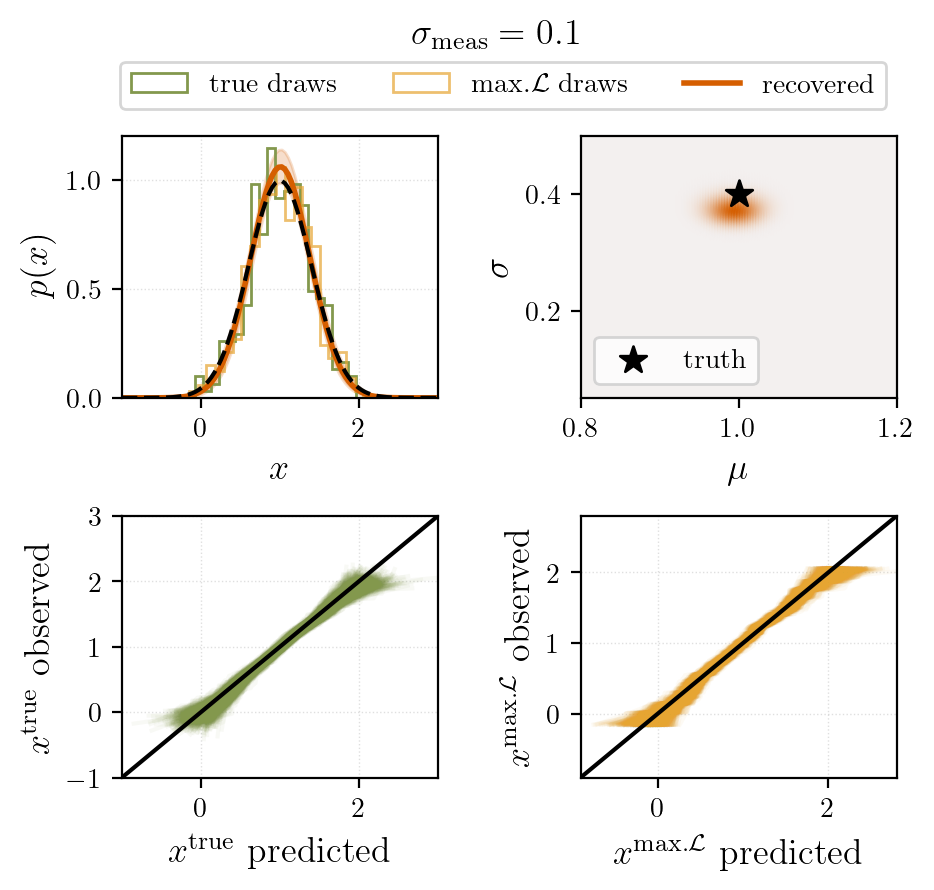

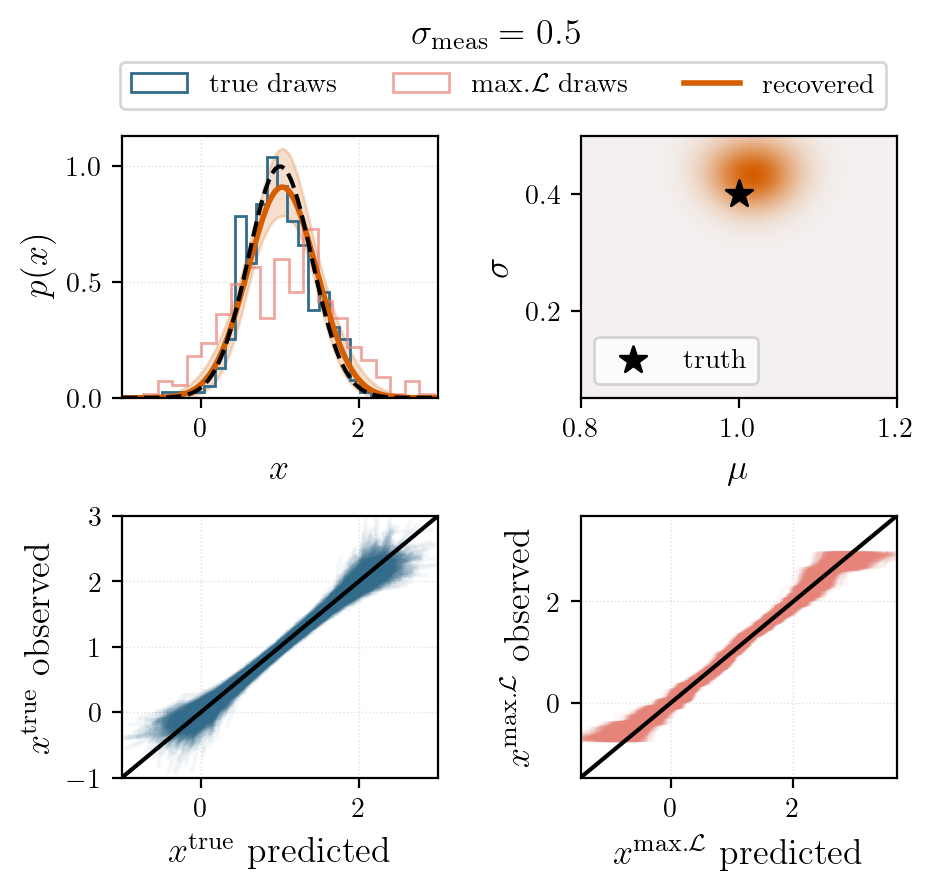

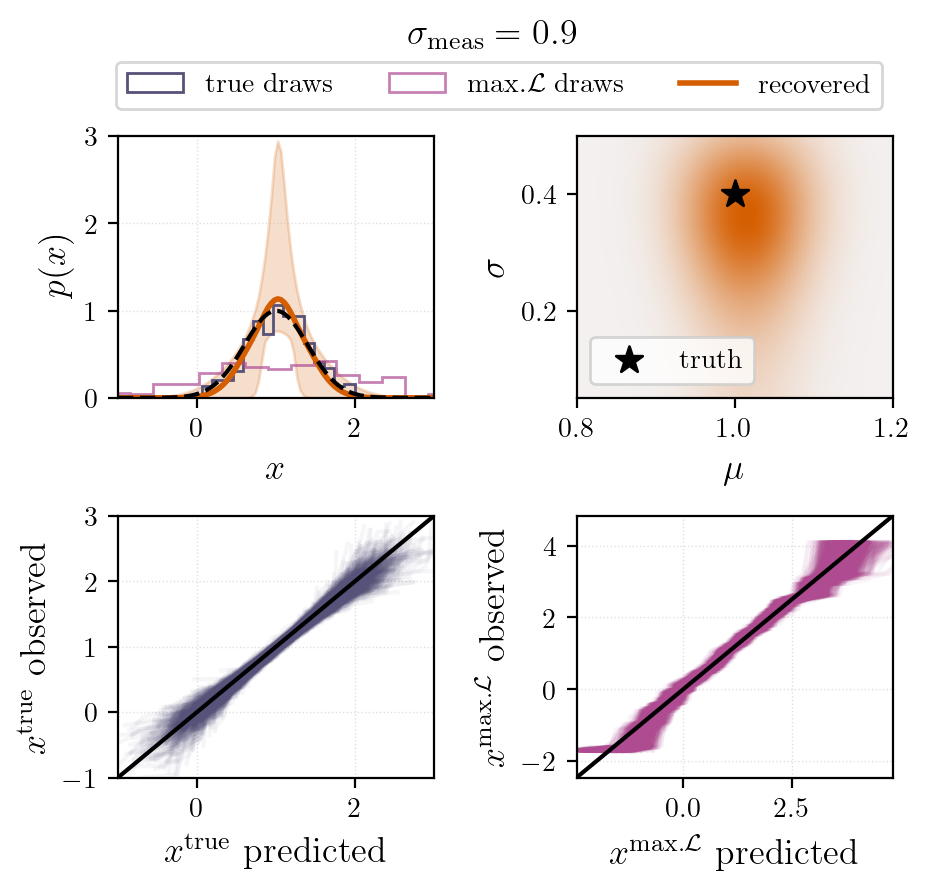

In [4]:
for sigma_meas, d in data.items(): 

    # unpack inputs
    x_true = d['x_true']
    x_maxL = d['x_maxL']
    x_grid = d['x_grid']
    p_x_true = d['p_x_true']
    lower, med, upper  = d['p_x_quantiles']
    mu_sig_grid = np.asarray([[mu,sig] for mu in d['mu_grid'] for sig in d['sigma_grid']])
    hL = d['hierarchical_likelihood_2D']
    PPC_traces_event = d['PPC_traces']['event']
    PPC_traces_maxL = d['PPC_traces']['maxL']

    # make figure
    fig, axes = plt.subplots(2,2, figsize=(6/1.2,5/1.2))

    color_true = colors_dict['true'][sigma_meas]
    color_maxL = colors_dict['maxL'][sigma_meas]

    axes[0][0].plot(x_grid, p_x_true, color='k', ls='--', zorder=5)
    axes[0][0].hist(x_true, density=True, color=color_true, histtype='step', bins=20, label='true draws')
    axes[0][0].hist(x_maxL, density=True, color=color_maxL, histtype='step', alpha=0.7, bins=20, label='max.$\mathcal{L}$ draws')
    axes[0][0].plot(x_grid, med, color='C3', lw=2, label='recovered')
    axes[0][0].fill_between(x_grid, lower, y2=upper, color='C3', alpha=0.2)
    axes[0][0].set_xlabel(r'$x$', fontsize=13)
    axes[0][0].set_ylabel(r'$p(x)$', fontsize=13)
    axes[0][0].grid(color='silver', ls=':', alpha=0.5)
    if sigma_meas==0.9: 
        axes[0][0].set_ylim(0,3)
    else:
        axes[0][0].set_ylim(0,)
    axes[0][0].set_xlim(x_grid[0], x_grid[-1])
    axes[0][0].legend(loc='lower left', bbox_to_anchor=(-0.05,1.05), ncols=3)

    axes[0][1].scatter(mu_sig_grid[:,0], mu_sig_grid[:,1], c=hL.flatten(), cmap=sns.light_palette("C3", as_cmap=True))
    axes[0][1].set_xlabel('$\mu$', fontsize=13)
    axes[0][1].set_ylabel('$\sigma$', fontsize=13)
    axes[0][1].scatter([mu_pop_true], [sigma_pop_true], color='k', marker='*', s=100, label='truth')
    axes[0][1].legend(loc='lower left')
    axes[0][1].set_xlim(0.8, 1.2)
    axes[0][1].set_ylim(0.05, 0.5)

    for p in PPC_traces_event:
        axes[1][0].plot(np.sort(p['y_rep']), np.sort(p['y']), color=color_true, alpha=0.05)
    diag = [-1,3]
    axes[1][0].plot(diag,diag, color='k')
    axes[1][0].grid(color='silver', alpha=0.5, ls=':')
    axes[1][0].set_xlabel(r'$x^{\rm true}$ predicted', fontsize=13)
    axes[1][0].set_ylabel(r'$x^{\rm true}$ observed', fontsize=13)
    axes[1][0].set_xlim(*diag)
    axes[1][0].set_ylim(*diag)

    for p in PPC_traces_maxL:
        axes[1][1].plot(np.sort(p['y_rep']), np.sort(p['y']), color=color_maxL, alpha=0.05)
    diag = [min(x_maxL)-0.75,max(x_maxL)+0.75]
    axes[1][1].plot(diag,diag, color='k')
    axes[1][1].grid(color='silver', alpha=0.5, ls=':')
    axes[1][1].set_xlabel(r'$x^{\mathrm{max.}\mathcal{L}}$ predicted', fontsize=13)
    axes[1][1].set_ylabel(r'$x^{\mathrm{max.}\mathcal{L}}$ observed', fontsize=13)
    axes[1][1].set_xlim(*diag)
    axes[1][1].set_ylim(*diag)

    plt.subplots_adjust(wspace=0.45, hspace=0.45)
    plt.suptitle(rf'$\sigma_{{\rm meas}} = {sigma_meas}$', y=1.02, fontsize=13)
    plt.savefig(save_names[sigma_meas], dpi=300, bbox_inches='tight')
    plt.show()

Figure 16

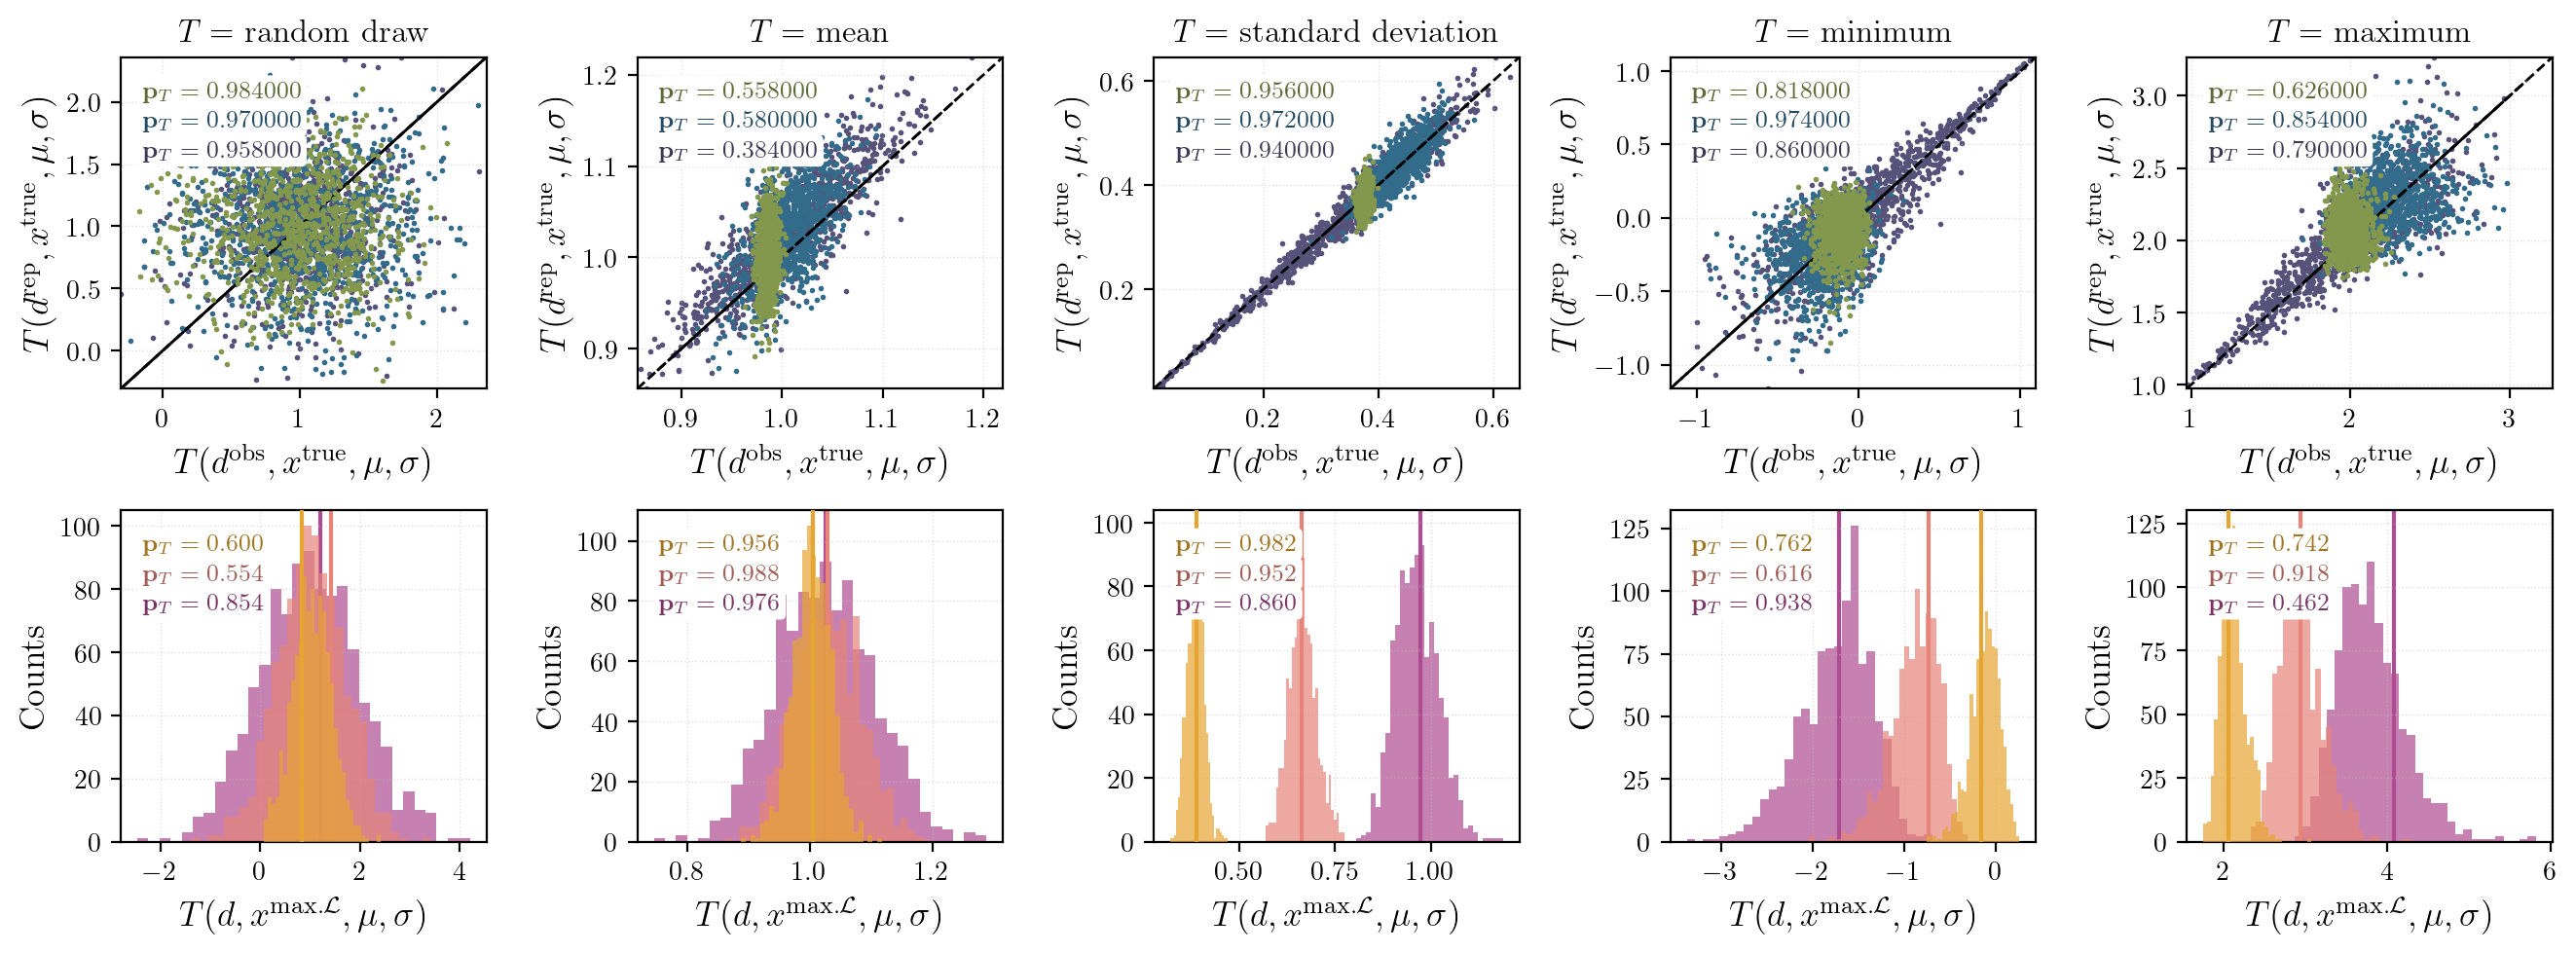

In [5]:
fig, axes = plt.subplots(2,5,figsize=(8*(5/3),5))

text_kws = dict(verticalalignment='top', zorder=6, fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.15', ec='white', fc='white', alpha=1))

for j, (sigma_meas, d) in enumerate(data.items()): 

    # unpack inputs
    T_dict_event = d['test_statistics']['event']
    T_dict_maxL = d['test_statistics']['maxL']

    zorder = 3-j

    # Plot 
    for i, k in enumerate(T_dict_event.keys()): 
        
        # Event level on top
        ax_top = axes[0,i]
        ax_top.scatter(T_dict_event[k]['T'], T_dict_event[k]['Trep'], color=colors_dict['true'][sigma_meas], s=1, zorder=zorder)
        
        dd = np.concatenate([T_dict_event[k]['T'], T_dict_event[k]['Trep']])
        diag = [min(dd), max(dd)]
        ax_top.plot(diag, diag, color='k', lw=1, ls='--')
        ax_top.set_xlim(*diag)
        ax_top.set_ylim(*diag)

        p = T_dict_event[k]['pvalue']
        p_color = plot_utils.darken_color(colors_dict['true'][sigma_meas])
        ax_top.text(0.06, 0.93-j*0.09, fr'$\mathbf{{p}}_T={p:3f}$', 
                    transform=ax_top.transAxes, color=p_color, **text_kws)

        ax_top.set_xlabel(r'$T(d^{\rm obs},x^{\mathrm{true}}, \mu,\sigma)$', fontsize=13)
        ax_top.set_ylabel(r'$T(d^{\rm rep},x^{\mathrm{true}}, \mu,\sigma)$', fontsize=13)

        ax_top.set_title(fr'$T=$ {k}')

        # Data (maxL) level on bottom
        ax_bottom = axes[1,i]
        ax_bottom.hist(T_dict_maxL[k]['Trep'], color=colors_dict['maxL'][sigma_meas], bins=30, alpha=0.7, zorder=zorder)
        ax_bottom.axvline(T_dict_maxL[k]['T'], color=colors_dict['maxL'][sigma_meas],  zorder=zorder)

        p = T_dict_maxL[k]['pvalue']
        p_color = plot_utils.darken_color(colors_dict['maxL'][sigma_meas])
        ax_bottom.text(0.06, 0.93-j*0.09, fr'$\mathbf{{p}}_T={p:.3f}$', 
                    transform=ax_bottom.transAxes, color=p_color, **text_kws)
        
        ax_bottom.set_ylabel('Counts', fontsize=13)
        ax_bottom.set_xlabel(r'$T(d,x^{\mathrm{max.}\mathcal{L}}, \mu,\sigma)$', fontsize=13)

for ax in axes.flatten(): 
    ax.grid(color='silver', alpha=0.5, ls=':')
plt.tight_layout()
plt.savefig('figure_16.png', dpi=300, bbox_inches='tight')
plt.show()